In [2]:
from google.colab import files
uploaded = files.upload()


Saving val_data.csv to val_data.csv


In [3]:
from google.colab import files
uploaded = files.upload()


Saving train_data.csv to train_data.csv


In [9]:
from google.colab import files
uploaded = files.upload()


Saving test_data.csv to test_data.csv


# **Baseline Models:**


## Logistic Regression:

In [20]:
import pandas as pd
from sklearn.linear_model import SGDClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack

# Load data
train_df = pd.read_csv("train_data.csv")
val_df = pd.read_csv("val_data.csv")

y_train = train_df["Is_Sarcastic"]
y_val = val_df["Is_Sarcastic"]

text_train = train_df["comment/headline"]
text_val = val_df["comment/headline"]

numeric_features = ["sentiment_score", "total_word_count", "exclamation_count", "question_count"]
numeric_train = train_df[numeric_features]
numeric_val = val_df[numeric_features]

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_text = tfidf.fit_transform(text_train)
X_val_text = tfidf.transform(text_val)

# Scale numeric features
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(numeric_train)
X_num_val_scaled = scaler.transform(numeric_val)

# Combine
X_train = hstack([X_train_text, X_num_train_scaled])
X_val = hstack([X_val_text, X_num_val_scaled])

# Trying different degrees of regularzation
alphas = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]
best_alpha = None
best_accuracy = 0
best_model = None

for alpha in alphas:
    print(f"\nTraining with alpha={alpha}")
    clf = SGDClassifier(
        loss='log_loss',
        penalty='l2',
        alpha=alpha,
        max_iter=2000,
        tol=1e-4,
        random_state=42,
        class_weight='balanced'
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {acc:.4f}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_alpha = alpha
        best_model = clf

print("\nBest alpha:", best_alpha)
print("Best Validation Accuracy:", best_accuracy)
print(classification_report(y_val, best_model.predict(X_val)))



Training with alpha=1e-05
Validation Accuracy: 0.6805

Training with alpha=5e-05
Validation Accuracy: 0.6920

Training with alpha=0.0001
Validation Accuracy: 0.6924

Training with alpha=0.0005
Validation Accuracy: 0.6864

Training with alpha=0.001
Validation Accuracy: 0.6787

Training with alpha=0.005
Validation Accuracy: 0.6498

Best alpha: 0.0001
Best Validation Accuracy: 0.6923757744341889
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      4198
           1       0.68      0.64      0.66      3711

    accuracy                           0.69      7909
   macro avg       0.69      0.69      0.69      7909
weighted avg       0.69      0.69      0.69      7909



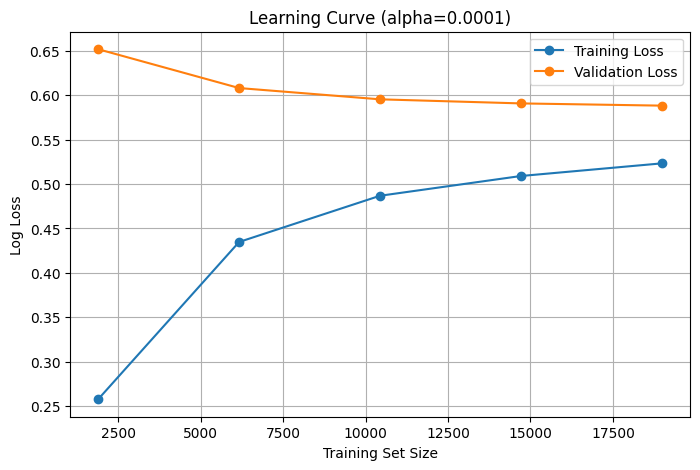

  Train Size |   Train Loss |     Val Loss
----------------------------------------
        1898 |       0.2576 |       0.6518
        6169 |       0.4347 |       0.6081
       10440 |       0.4868 |       0.5954
       14711 |       0.5090 |       0.5908
       18982 |       0.5233 |       0.5883


In [34]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Use your best alpha
clf = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=best_alpha,
    max_iter=2000,
    tol=1e-4,
    random_state=42,
    class_weight='balanced'
)

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    clf,
    X_train,
    y_train,
    cv=5,  # 5-fold cross-validation
    train_sizes=np.linspace(0.1, 1.0, 5),  # test at 10%, 25%, 50%, 75%, 100% of train data
    scoring='neg_log_loss',
    n_jobs=-1
)

# Take the mean over the CV folds and flip sign (since scores are negative log loss)
train_loss_mean = -train_scores.mean(axis=1)
val_loss_mean = -val_scores.mean(axis=1)

# Plot learning curve (loss)
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_loss_mean, 'o-', label='Training Loss')
plt.plot(train_sizes, val_loss_mean, 'o-', label='Validation Loss')
plt.xlabel('Training Set Size')
plt.ylabel('Log Loss')
plt.title(f'Learning Curve (alpha={best_alpha})')
plt.legend()
plt.grid(True)
plt.show()

# Print numbers
print(f"{'Train Size':>12} | {'Train Loss':>12} | {'Val Loss':>12}")
print("-" * 40)
for size, train_l, val_l in zip(train_sizes, train_loss_mean, val_loss_mean):
    print(f"{size:12} | {train_l:12.4f} | {val_l:12.4f}")


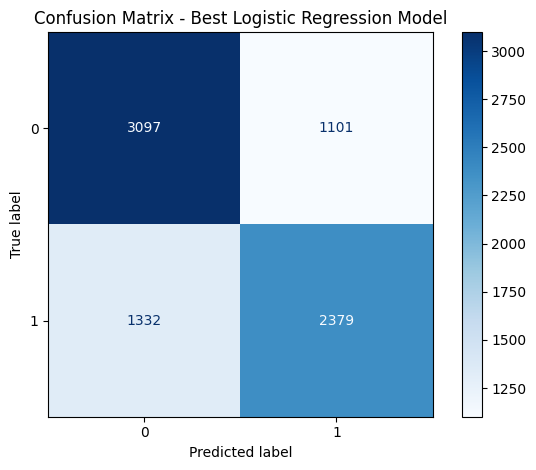

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

# Predict and plot
ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val, cmap='Blues')
plt.title('Confusion Matrix - Best Logistic Regression Model')
plt.tight_layout()
plt.show()


In [11]:
# --- Load Test Data ---
test_df = pd.read_csv("test_data.csv")
text_test = test_df["comment/headline"]
numeric_test = test_df[numeric_features]

# --- Transform Test Data (use same TF-IDF and Scaler from training) ---
X_test_text = tfidf.transform(text_test)
X_test_numeric_scaled = scaler.transform(numeric_test)
X_test = hstack([X_test_text, X_test_numeric_scaled])

# --- Predict using best_model ---
y_test_pred = best_model.predict(X_test)

# --- Save or show predictions ---
# If test set has true labels:
if "Is_Sarcastic" in test_df.columns:
    y_test_true = test_df["Is_Sarcastic"]
    print("\n--- Test Set Evaluation ---")
    print(classification_report(y_test_true, y_test_pred))
else:
    print("\n--- Predictions on Unlabeled Test Set ---")
    print(y_test_pred)  # or save to CSV

    # Optional: Save to file
    pd.DataFrame({
        "comment/headline": test_df["comment/headline"],
        "Predicted_Is_Sarcastic": y_test_pred
    }).to_csv("test_predictions.csv", index=False)



--- Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      4198
           1       0.69      0.65      0.67      3712

    accuracy                           0.70      7910
   macro avg       0.69      0.69      0.69      7910
weighted avg       0.69      0.70      0.69      7910



# SVM

Implemented using LinearSVC instead of classical SVC as classical method was too slow for our large dataset

Tuning C parameter...

Training LinearSVC with C=0.01...
Validation Accuracy: 0.6902

Training LinearSVC with C=0.1...
Validation Accuracy: 0.6926

Training LinearSVC with C=1...
Validation Accuracy: 0.6749

Training LinearSVC with C=10...
Validation Accuracy: 0.6469

Training LinearSVC with C=100...
Validation Accuracy: 0.6372

Best C: 0.1 with validation accuracy: 0.6926

Classification report for best model:
              precision    recall  f1-score   support

           0       0.71      0.72      0.71      4198
           1       0.68      0.66      0.67      3711

    accuracy                           0.69      7909
   macro avg       0.69      0.69      0.69      7909
weighted avg       0.69      0.69      0.69      7909



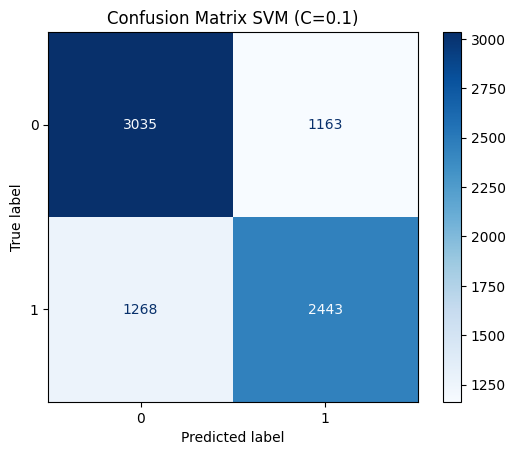

In [47]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import hstack

# Load data
train_df = pd.read_csv("train_data.csv")
val_df = pd.read_csv("val_data.csv")

y_train = train_df["Is_Sarcastic"]
y_val = val_df["Is_Sarcastic"]

text_train = train_df["comment/headline"]
text_val = val_df["comment/headline"]

numeric_features = ["sentiment_score", "total_word_count", "exclamation_count", "question_count"]
numeric_train = train_df[numeric_features]
numeric_val = val_df[numeric_features]

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_text = tfidf.fit_transform(text_train)
X_val_text = tfidf.transform(text_val)

# Scale numeric features
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(numeric_train)
X_num_val_scaled = scaler.transform(numeric_val)

# Combine features (LinearSVC supports sparse input directly)
X_train = hstack([X_train_text, X_num_train_scaled])
X_val = hstack([X_val_text, X_num_val_scaled])

# Define a range of C values to try
c_values = [0.01, 0.1, 1, 10, 100]

best_c = None
best_acc = 0
best_model = None

print("Tuning C parameter...")
for c in c_values:
    print(f"\nTraining LinearSVC with C={c}...")
    clf = LinearSVC(class_weight='balanced', C=c, max_iter=10000, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_c = c
        best_model = clf

print(f"\nBest C: {best_c} with validation accuracy: {best_acc:.4f}")

print("\nClassification report for best model:")
y_pred_best = best_model.predict(X_val)
print(classification_report(y_val, y_pred_best))

ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val, cmap='Blues')
plt.title(f"Confusion Matrix SVM (C={best_c})")
plt.show()

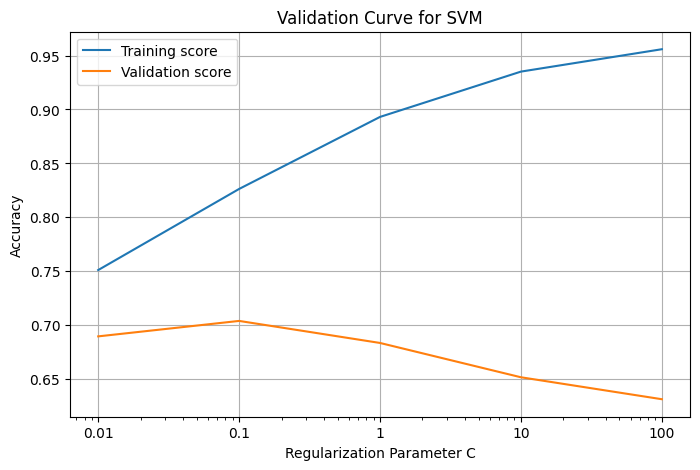

   C value |  Train Acc |    Val Acc
------------------------------------
    0.0100 |     0.7511 |     0.6896
    0.1000 |     0.8263 |     0.7039
    1.0000 |     0.8931 |     0.6835
   10.0000 |     0.9351 |     0.6517
  100.0000 |     0.9559 |     0.6313


In [42]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np

param_range = c_values
train_scores, val_scores = validation_curve(
    LinearSVC(class_weight='balanced', max_iter=10000, random_state=42),
    X_train,
    y_train,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",  # or 'f1'
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8, 5))
plt.semilogx(param_range, train_mean, label="Training score")
plt.semilogx(param_range, val_mean, label="Validation score")
plt.xlabel("Regularization Parameter C")
plt.ylabel("Accuracy")
plt.title("Validation Curve for SVM")
plt.legend()
plt.grid(True)
plt.xticks(param_range, [str(c) for c in param_range])

plt.show()

# Print the numbers
print(f"{'C value':>10} | {'Train Acc':>10} | {'Val Acc':>10}")
print("-" * 36)
for c, train_acc, val_acc in zip(param_range, train_mean, val_mean):
    print(f"{c:10.4f} | {train_acc:10.4f} | {val_acc:10.4f}")


In [13]:
# --- Load test data ---
test_df = pd.read_csv("test_data.csv")
text_test = test_df["comment/headline"]
numeric_test = test_df[numeric_features]

# --- Transform test data ---
X_test_text = tfidf.transform(text_test)
X_test_numeric_scaled = scaler.transform(numeric_test)

# Combine
X_test = hstack([X_test_text, X_test_numeric_scaled])

# --- Predict on test data ---
y_test_pred = best_model.predict(X_test)

# --- If test labels exist, evaluate ---
if "Is_Sarcastic" in test_df.columns:
    y_test_true = test_df["Is_Sarcastic"]
    print("\n--- Test Set Evaluation ---")
    print(classification_report(y_test_true, y_test_pred))
else:
    print("\n--- Predictions on Unlabeled Test Set ---")
    print(y_test_pred)

    # Optional: save predictions to CSV
    pd.DataFrame({
        "comment/headline": test_df["comment/headline"],
        "Predicted_Is_Sarcastic": y_test_pred
    }).to_csv("test_predictions_linearSVC.csv", index=False)



--- Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.71      0.73      0.72      4198
           1       0.68      0.67      0.67      3712

    accuracy                           0.70      7910
   macro avg       0.70      0.70      0.70      7910
weighted avg       0.70      0.70      0.70      7910



## Random Forest

Random Forest Validation Accuracy: 0.6797319509419648
              precision    recall  f1-score   support

           0       0.68      0.76      0.72      4198
           1       0.69      0.58      0.63      3711

    accuracy                           0.68      7909
   macro avg       0.68      0.67      0.67      7909
weighted avg       0.68      0.68      0.68      7909



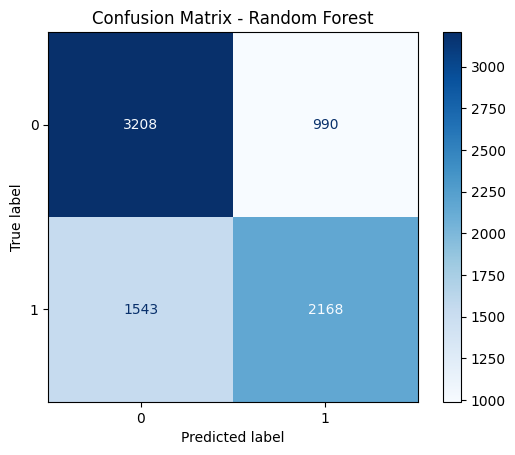

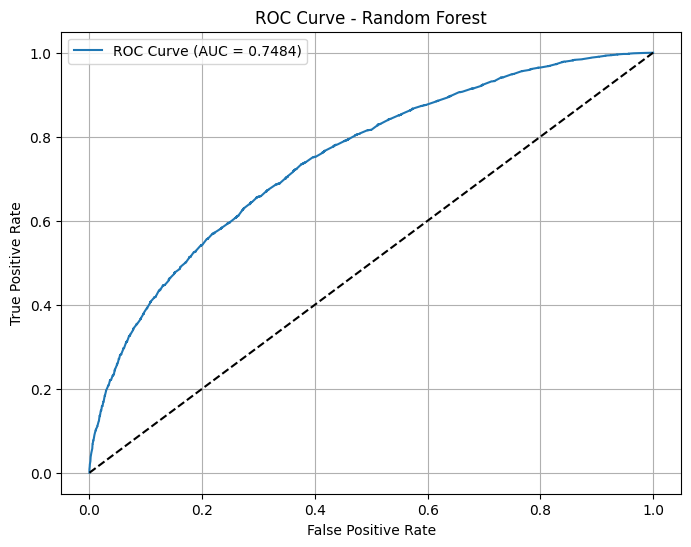

Top 20 important features:
total_word_count     : 0.0184
sentiment_score      : 0.0153
man                  : 0.0144
exclamation_count    : 0.0113
trump                : 0.0104
yeah                 : 0.0076
report               : 0.0056
area                 : 0.0054
nation               : 0.0053
donald               : 0.0040
just                 : 0.0038
obviously            : 0.0037
like                 : 0.0037
right                : 0.0031
don                  : 0.0030
new                  : 0.0029
question_count       : 0.0028
clearly              : 0.0027
think                : 0.0026
says                 : 0.0025


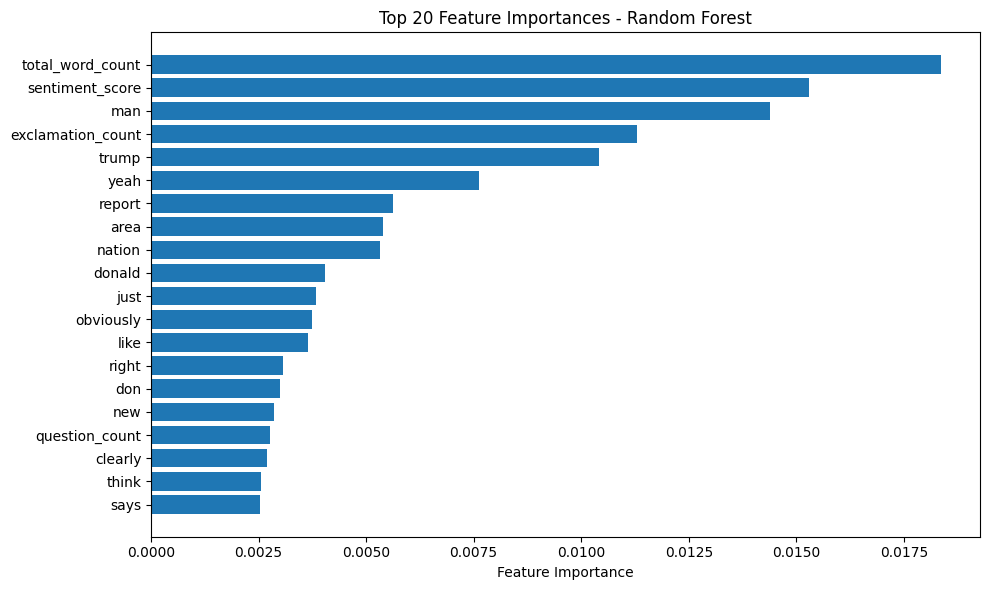

In [44]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from scipy.sparse import hstack
import matplotlib.pyplot as plt

# Load data
train_df = pd.read_csv("train_data.csv")
val_df = pd.read_csv("val_data.csv")

y_train = train_df["Is_Sarcastic"]
y_val = val_df["Is_Sarcastic"]

text_train = train_df["comment/headline"]
text_val = val_df["comment/headline"]

numeric_features = ["sentiment_score", "total_word_count", "exclamation_count", "question_count"]
numeric_train = train_df[numeric_features]
numeric_val = val_df[numeric_features]

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_text = tfidf.fit_transform(text_train)
X_val_text = tfidf.transform(text_val)

# Scale numeric features
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(numeric_train)
X_num_val_scaled = scaler.transform(numeric_val)

# Combine features (RandomForest requires dense)
X_train = hstack([X_train_text, X_num_train_scaled]).toarray()
X_val = hstack([X_val_text, X_num_val_scaled]).toarray()

# Train Random Forest with fixed n_estimators=100
clf_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf_rf.fit(X_train, y_train)
y_pred = clf_rf.predict(X_val)
y_pred_proba = clf_rf.predict_proba(X_val)[:, 1]  # probability of positive class


print("Random Forest Validation Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

ConfusionMatrixDisplay.from_estimator(clf_rf, X_val, y_val, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# 2. ROC Curve + AUC
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
auc_score = roc_auc_score(y_val, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line for random guess
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# Feature names: combine TF-IDF vocab and numeric features
feature_names = list(tfidf.get_feature_names_out()) + numeric_features

# Get feature importances from the trained RF model
importances = clf_rf.feature_importances_

# Sort features by importance descending
indices = np.argsort(importances)[::-1]

# Print top 20 features with importance
print("Top 20 important features:")
for i in indices[:20]:
    print(f"{feature_names[i]:<20} : {importances[i]:.4f}")

# Plot top 20 feature importances
plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances - Random Forest")
plt.barh(range(20), importances[indices[:20]][::-1], align='center')
plt.yticks(range(20), [feature_names[i] for i in indices[:20]][::-1])
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()



In [15]:
# --- Load test data ---
test_df = pd.read_csv("test_data.csv")
text_test = test_df["comment/headline"]
numeric_test = test_df[numeric_features]

# --- Transform test data ---
X_test_text = tfidf.transform(text_test)
X_test_numeric_scaled = scaler.transform(numeric_test)

# Combine and convert to dense (required for RandomForest)
X_test = hstack([X_test_text, X_test_numeric_scaled]).toarray()

# --- Predict on test data ---
y_test_pred = clf_rf.predict(X_test)

# --- Evaluate if labels available ---
if "Is_Sarcastic" in test_df.columns:
    y_test_true = test_df["Is_Sarcastic"]
    print("\n--- Test Set Evaluation ---")
    print(classification_report(y_test_true, y_test_pred))
else:
    print("\n--- Predictions on Unlabeled Test Set ---")
    print(y_test_pred)

    # Optionally save predictions to CSV
    pd.DataFrame({
        "comment/headline": test_df["comment/headline"],
        "Predicted_Is_Sarcastic": y_test_pred
    }).to_csv("test_predictions_rf.csv", index=False)



--- Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.68      0.76      0.72      4198
           1       0.68      0.59      0.64      3712

    accuracy                           0.68      7910
   macro avg       0.68      0.68      0.68      7910
weighted avg       0.68      0.68      0.68      7910



# ---------------------------------------------------------------------------


# Neural Network

## 1. NN with 2 hidden layers and SGD optimizer

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input


# ---------- Load training data ----------
train_df = pd.read_csv("train_data.csv")
y_train = train_df["Is_Sarcastic"].values
text_train = train_df["comment/headline"]
numeric_train = train_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- Load validation data ----------
val_df = pd.read_csv("val_data.csv")
y_val = val_df["Is_Sarcastic"].values
text_val = val_df["comment/headline"]
numeric_val = val_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- TF-IDF vectorization ----------
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)

# ---------- Normalize numeric features ----------
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(numeric_train)
X_numeric_val = scaler.transform(numeric_val)

# ---------- Combine text and numeric features ----------
X_train = hstack([X_text_train, X_numeric_train]).toarray()
X_val = hstack([X_text_val, X_numeric_val]).toarray()

# ---------- Build basic neural network ----------
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # <-- use Input layer here
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ---------- Compile the model ----------
model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

# ---------- Train the model ----------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# ---------- Evaluate on validation set ----------
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")

# ---------- Generate classification report ----------
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred))


Epoch 1/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5325 - loss: 0.6876 - val_accuracy: 0.5534 - val_loss: 0.6818
Epoch 2/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5503 - loss: 0.6823 - val_accuracy: 0.5533 - val_loss: 0.6797
Epoch 3/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5515 - loss: 0.6805 - val_accuracy: 0.5541 - val_loss: 0.6781
Epoch 4/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5549 - loss: 0.6773 - val_accuracy: 0.5559 - val_loss: 0.6764
Epoch 5/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5566 - loss: 0.6770 - val_accuracy: 0.5568 - val_loss: 0.6741
Epoch 6/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5641 - loss: 0.6749 - val_accuracy: 0.5682 - val_loss: 0.6709
Epoch 7/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5756 - loss: 0.6709 - val_accuracy: 0.5898 - val_loss: 0.6668
Epoch 8/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5980 - loss: 0.6656 - val_accuracy: 0.

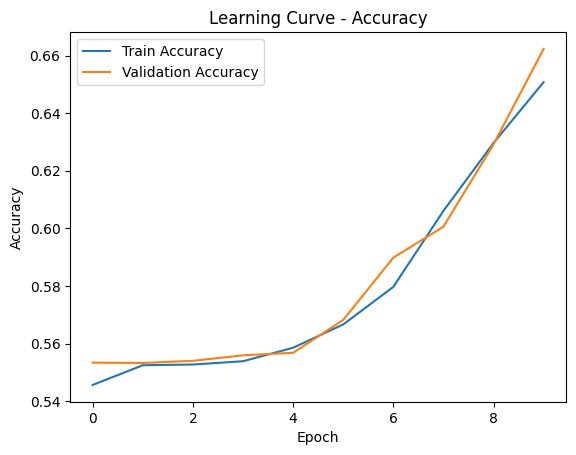

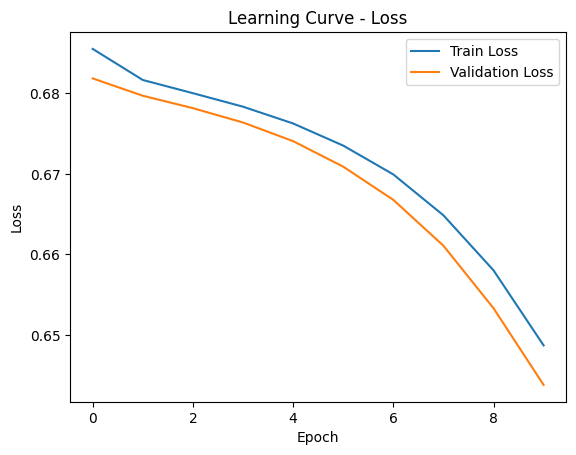

Training Loss per epoch:
[0.6854994893074036, 0.6816445589065552, 0.6800060272216797, 0.6783304214477539, 0.6762470006942749, 0.6735019087791443, 0.6699255108833313, 0.6648521423339844, 0.6580244898796082, 0.648703932762146]

Validation Loss per epoch:
[0.6818394660949707, 0.6796883940696716, 0.6781490445137024, 0.6763677000999451, 0.6740558743476868, 0.6708886027336121, 0.666767954826355, 0.6610766649246216, 0.6533203721046448, 0.643799901008606]

Training Accuracy per epoch:
[0.5456843972206116, 0.5525118112564087, 0.5527646541595459, 0.5539025664329529, 0.5585805773735046, 0.5666722655296326, 0.5796948671340942, 0.6060771942138672, 0.6296358704566956, 0.6507501602172852]

Validation Accuracy per epoch:
[0.5534201264381409, 0.5532937049865723, 0.5540523529052734, 0.5559489130973816, 0.5568339824676514, 0.5682134032249451, 0.5898343920707703, 0.6005815863609314, 0.6291566491127014, 0.6622834801673889]


In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.show()

# After model.fit()

print("Training Loss per epoch:")
print(history.history['loss'])

print("\nValidation Loss per epoch:")
print(history.history['val_loss'])

print("\nTraining Accuracy per epoch:")
print(history.history['accuracy'])

print("\nValidation Accuracy per epoch:")
print(history.history['val_accuracy'])



#--------------------------------

#2. NN with 3 hidden layers and SGD optimizer:

In [48]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input


# ---------- Load training data ----------
train_df = pd.read_csv("train_data.csv")
y_train = train_df["Is_Sarcastic"].values
text_train = train_df["comment/headline"]
numeric_train = train_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- Load validation data ----------
val_df = pd.read_csv("val_data.csv")
y_val = val_df["Is_Sarcastic"].values
text_val = val_df["comment/headline"]
numeric_val = val_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- TF-IDF vectorization ----------
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)

# ---------- Normalize numeric features ----------
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(numeric_train)
X_numeric_val = scaler.transform(numeric_val)

# ---------- Combine text and numeric features ----------
X_train = hstack([X_text_train, X_numeric_train]).toarray()
X_val = hstack([X_text_val, X_numeric_val]).toarray()

# ---------- Build basic neural network ----------
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # Input layer
    Dense(256, activation='relu'),    # Increased units from 128 to 256
    Dense(128, activation='relu'),    # Added new layer with 128 units
    Dense(64, activation='relu'),     # Existing 64 units layer
    Dense(1, activation='sigmoid')    # Output layer
])

# ---------- Compile the model ----------
model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

# ---------- Train the model ----------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# ---------- Evaluate on validation set ----------
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")

# ---------- Generate classification report ----------
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred))


Epoch 1/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5443 - loss: 0.6896 - val_accuracy: 0.5535 - val_loss: 0.6843
Epoch 2/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5487 - loss: 0.6844 - val_accuracy: 0.5538 - val_loss: 0.6808
Epoch 3/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5576 - loss: 0.6789 - val_accuracy: 0.5602 - val_loss: 0.6787
Epoch 4/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5535 - loss: 0.6798 - val_accuracy: 0.5602 - val_loss: 0.6761
Epoch 5/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5605 - loss: 0.6773 - val_accuracy: 0.5706 - val_loss: 0.6727
Epoch 6/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5732 - loss: 0.6742 - val_accuracy: 0.6006 - val_loss: 0.6676
Epoch 7/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6026 - loss: 0.6677 - val_accuracy: 0.6202 - val_loss: 0.6585
Epoch 8/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6310 - loss: 0.6557 - val_accuracy: 0.

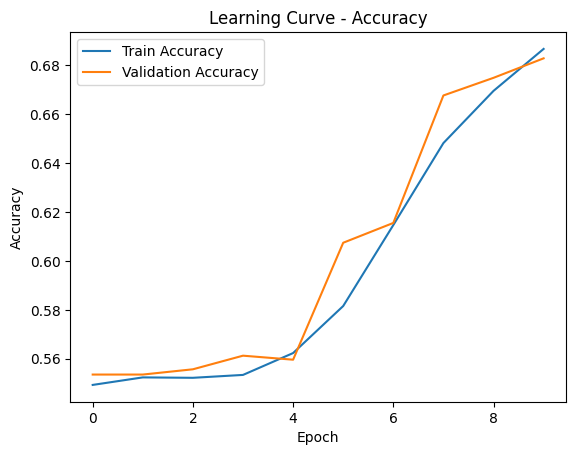

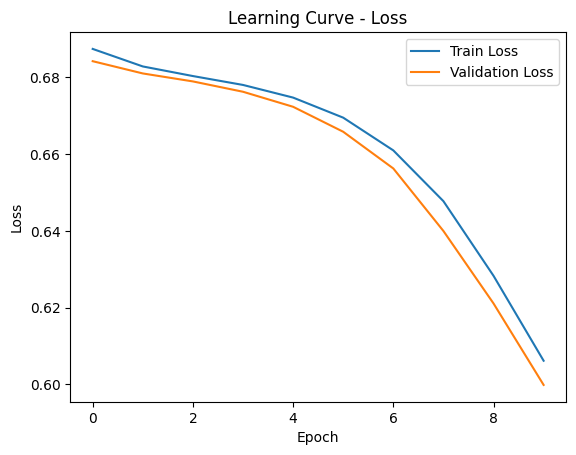

Training Loss per epoch:
[0.6874372363090515, 0.6828691363334656, 0.6803646683692932, 0.6780475974082947, 0.6747491359710693, 0.669518232345581, 0.6609845161437988, 0.6477498412132263, 0.6282992959022522, 0.606151282787323]

Validation Loss per epoch:
[0.684238076210022, 0.6810439229011536, 0.6789646744728088, 0.6762709617614746, 0.6723528504371643, 0.6658421158790588, 0.6562742590904236, 0.6399791240692139, 0.6210899353027344, 0.5998446345329285]

Training Accuracy per epoch:
[0.5493088364601135, 0.5523853898048401, 0.5522167682647705, 0.5533968210220337, 0.5623314380645752, 0.5815492272377014, 0.6146324872970581, 0.6481372117996216, 0.669462263584137, 0.686614990234375]

Validation Accuracy per epoch:
[0.5535466074943542, 0.5535466074943542, 0.5556960701942444, 0.5612593293190002, 0.5596156120300293, 0.6074092984199524, 0.615501344203949, 0.6675938963890076, 0.6748008728027344, 0.6827664971351624]


In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.show()

# After model.fit()

print("Training Loss per epoch:")
print(history.history['loss'])

print("\nValidation Loss per epoch:")
print(history.history['val_loss'])

print("\nTraining Accuracy per epoch:")
print(history.history['accuracy'])

print("\nValidation Accuracy per epoch:")
print(history.history['val_accuracy'])



# -----------------------------------

# 3. NN with 2 hidden layers and 'adam' optimizer

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input



# ---------- Load training data ----------
train_df = pd.read_csv("train_data.csv")
y_train = train_df["Is_Sarcastic"].values
text_train = train_df["comment/headline"]
numeric_train = train_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- Load validation data ----------
val_df = pd.read_csv("val_data.csv")
y_val = val_df["Is_Sarcastic"].values
text_val = val_df["comment/headline"]
numeric_val = val_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- TF-IDF vectorization ----------
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)

# ---------- Normalize numeric features ----------
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(numeric_train)
X_numeric_val = scaler.transform(numeric_val)

# ---------- Combine text and numeric features ----------
X_train = hstack([X_text_train, X_numeric_train]).toarray()
X_val = hstack([X_text_val, X_numeric_val]).toarray()

# ---------- Build basic neural network ----------
model = Sequential([
    Input(shape=(X_train.shape[1],)),  # <-- use Input layer here
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# ---------- Compile the model ----------
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ---------- Train the model ----------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# ---------- Evaluate on validation set ----------
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")

# ---------- Generate classification report ----------
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred))


Epoch 1/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6419 - loss: 0.6251 - val_accuracy: 0.7187 - val_loss: 0.5481
Epoch 2/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7409 - loss: 0.5189 - val_accuracy: 0.7263 - val_loss: 0.5422
Epoch 3/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7719 - loss: 0.4768 - val_accuracy: 0.7278 - val_loss: 0.5421
Epoch 4/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8108 - loss: 0.4135 - val_accuracy: 0.7241 - val_loss: 0.5775
Epoch 5/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8535 - loss: 0.3371 - val_accuracy: 0.7191 - val_loss: 0.6195
Epoch 6/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9011 - loss: 0.2411 - val_accuracy: 0.7094 - val_loss: 0.7138
Epoch 7/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9382 - loss: 0.1645 - val_accuracy: 0.7044 - val_loss: 0.8915
Epoch 8/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9650 - loss: 0.1035 - val_accuracy: 0.

# Overfit!

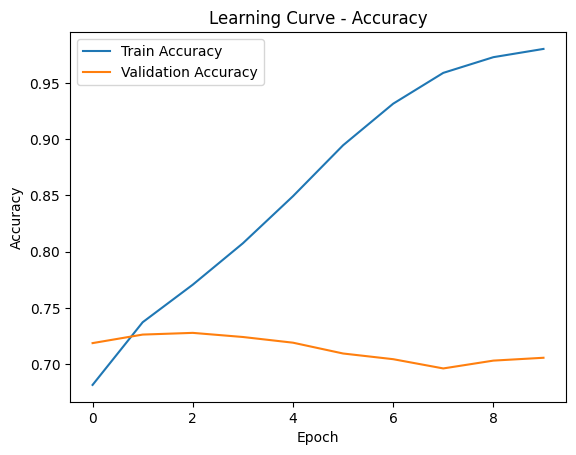

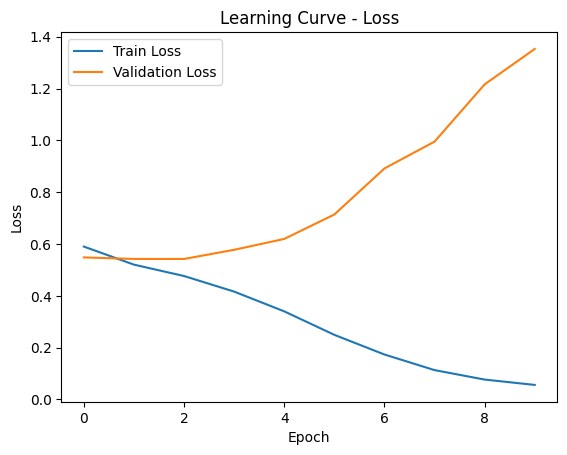

Training Loss per epoch:
[0.5899736285209656, 0.5202624797821045, 0.4763568937778473, 0.4161967933177948, 0.33989596366882324, 0.24931268393993378, 0.17338165640830994, 0.11315375566482544, 0.07662953436374664, 0.05597423389554024]

Validation Loss per epoch:
[0.5481051802635193, 0.542222261428833, 0.5421266555786133, 0.5775057673454285, 0.6194904446601868, 0.7137707471847534, 0.8914614319801331, 0.995008111000061, 1.215975284576416, 1.3528492450714111]

Training Accuracy per epoch:
[0.6815155148506165, 0.7372303009033203, 0.7706085443496704, 0.8074005246162415, 0.8492498397827148, 0.8945128321647644, 0.9314733743667603, 0.9588671326637268, 0.9728169441223145, 0.980150043964386]

Validation Accuracy per epoch:
[0.718674898147583, 0.7262611985206604, 0.7277784943580627, 0.724111795425415, 0.7190542221069336, 0.7094449400901794, 0.7043874263763428, 0.6961688995361328, 0.7031230330467224, 0.7056517601013184]


In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.show()

# After model.fit()

print("Training Loss per epoch:")
print(history.history['loss'])

print("\nValidation Loss per epoch:")
print(history.history['val_loss'])

print("\nTraining Accuracy per epoch:")
print(history.history['accuracy'])

print("\nValidation Accuracy per epoch:")
print(history.history['val_accuracy'])



#--------------------------

# 4. NN with 2 hidden layers, dropout to adress overfitting, 'adam' optimizer

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout



# ---------- Load training data ----------
train_df = pd.read_csv("train_data.csv")
y_train = train_df["Is_Sarcastic"].values
text_train = train_df["comment/headline"]
numeric_train = train_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- Load validation data ----------
val_df = pd.read_csv("val_data.csv")
y_val = val_df["Is_Sarcastic"].values
text_val = val_df["comment/headline"]
numeric_val = val_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- TF-IDF vectorization ----------
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)

# ---------- Normalize numeric features ----------
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(numeric_train)
X_numeric_val = scaler.transform(numeric_val)

# ---------- Combine text and numeric features ----------
X_train = hstack([X_text_train, X_numeric_train]).toarray()
X_val = hstack([X_text_val, X_numeric_val]).toarray()

# ---------- Build basic neural network ----------
model = Sequential([
     Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Drop 50% of nodes
    Dense(64, activation='relu'),
    Dropout(0.3),  # Drop 30% of nodes
    Dense(1, activation='sigmoid')
])

# ---------- Compile the model ----------
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ---------- Train the model ----------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

# ---------- Evaluate on validation set ----------
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")

# ---------- Generate classification report ----------
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred))


Epoch 1/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6098 - loss: 0.6515 - val_accuracy: 0.7158 - val_loss: 0.5543
Epoch 2/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7316 - loss: 0.5374 - val_accuracy: 0.7249 - val_loss: 0.5445
Epoch 3/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7513 - loss: 0.5144 - val_accuracy: 0.7255 - val_loss: 0.5413
Epoch 4/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7624 - loss: 0.4906 - val_accuracy: 0.7309 - val_loss: 0.5435
Epoch 5/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7838 - loss: 0.4609 - val_accuracy: 0.7313 - val_loss: 0.5409
Epoch 6/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8038 - loss: 0.4277 - val_accuracy: 0.7314 - val_loss: 0.5487
Epoch 7/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8233 - loss: 0.3959 - val_accuracy: 0.7289 - val_loss: 0.5658
Epoch 8/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8424 - loss: 0.3594 - val_accuracy: 0.

# Better but still overfitting

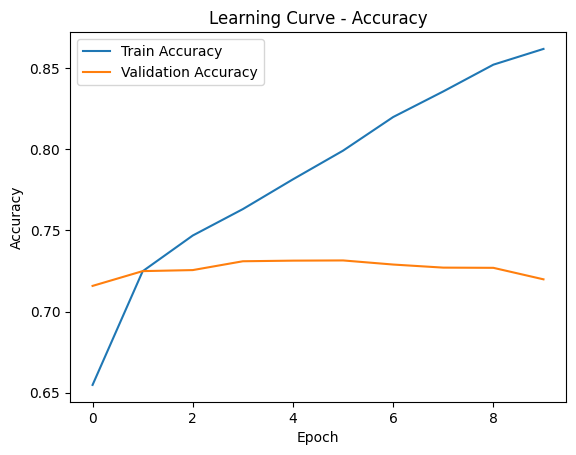

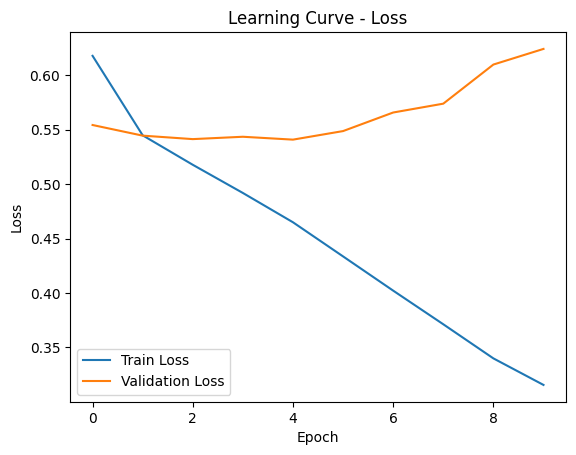

Training Loss per epoch:
[0.6178213357925415, 0.5448160767555237, 0.5177553296089172, 0.4918663203716278, 0.46494075655937195, 0.43358713388442993, 0.40215736627578735, 0.37127137184143066, 0.33993425965309143, 0.31555822491645813]

Validation Loss per epoch:
[0.5542901754379272, 0.5445204377174377, 0.5413336157798767, 0.5434941649436951, 0.5408567786216736, 0.5487154722213745, 0.5657703280448914, 0.5738921165466309, 0.6098129749298096, 0.6241742372512817]

Training Accuracy per epoch:
[0.6547960042953491, 0.7247977256774902, 0.7467970252037048, 0.7630647420883179, 0.7813975214958191, 0.7990559935569763, 0.8197488188743591, 0.835510790348053, 0.851989209651947, 0.8616824150085449]

Validation Accuracy per epoch:
[0.7157668471336365, 0.7248703837394714, 0.725502610206604, 0.7309394478797913, 0.7313187718391418, 0.7314451932907104, 0.7289164066314697, 0.7270198464393616, 0.726893424987793, 0.7198128700256348]


In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.show()

# After model.fit()

print("Training Loss per epoch:")
print(history.history['loss'])

print("\nValidation Loss per epoch:")
print(history.history['val_loss'])

print("\nTraining Accuracy per epoch:")
print(history.history['accuracy'])

print("\nValidation Accuracy per epoch:")
print(history.history['val_accuracy'])



# 5. Adding extra stopping to adress overfitting

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout




# ---------- Load training data ----------
train_df = pd.read_csv("train_data.csv")
y_train = train_df["Is_Sarcastic"].values
text_train = train_df["comment/headline"]
numeric_train = train_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- Load validation data ----------
val_df = pd.read_csv("val_data.csv")
y_val = val_df["Is_Sarcastic"].values
text_val = val_df["comment/headline"]
numeric_val = val_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- TF-IDF vectorization ----------
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)

# ---------- Normalize numeric features ----------
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(numeric_train)
X_numeric_val = scaler.transform(numeric_val)

# ---------- Combine text and numeric features ----------
X_train = hstack([X_text_train, X_numeric_train]).toarray()
X_val = hstack([X_text_val, X_numeric_val]).toarray()

# ---------- Build basic neural network ----------
model = Sequential([
     Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Drop 50% of nodes
    Dense(64, activation='relu'),
    Dropout(0.3),  # Drop 30% of nodes
    Dense(1, activation='sigmoid')
])


early_stop = EarlyStopping(
    monitor='val_loss',       # Watch validation loss
    patience=2,               # Stop if val_loss doesn't improve for 2 epochs
    restore_best_weights=True
)

# ---------- Compile the model ----------
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ---------- Train the model with EarlyStopping ----------
history = model.fit(
    X_train, y_train,
    epochs=10,                # Allow more epochs, EarlyStopping will cut it short
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],  # Add EarlyStopping callback here
    verbose=1
)

# ---------- Evaluate on validation set ----------
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")

# ---------- Generate classification report ----------
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred))


Epoch 1/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6084 - loss: 0.6495 - val_accuracy: 0.7191 - val_loss: 0.5558
Epoch 2/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7244 - loss: 0.5423 - val_accuracy: 0.7244 - val_loss: 0.5445
Epoch 3/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7451 - loss: 0.5145 - val_accuracy: 0.7306 - val_loss: 0.5417
Epoch 4/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7640 - loss: 0.4869 - val_accuracy: 0.7295 - val_loss: 0.5400
Epoch 5/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7873 - loss: 0.4585 - val_accuracy: 0.7317 - val_loss: 0.5417
Epoch 6/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8039 - loss: 0.4252 - val_accuracy: 0.7293 - val_loss: 0.5522
Validation Accuracy: 0.7295
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.72      0.79      0.76      4198
           1       0.74      0.66      0.70      3711


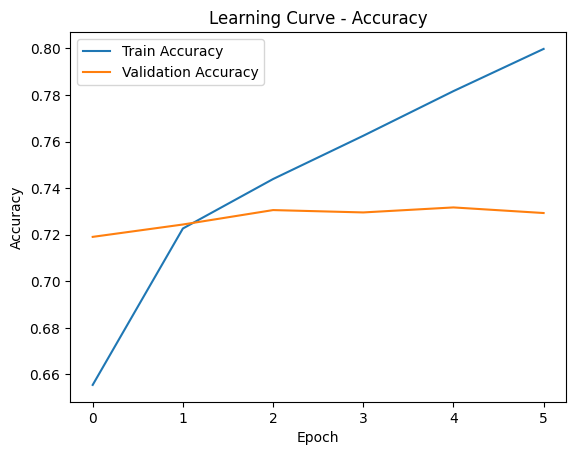

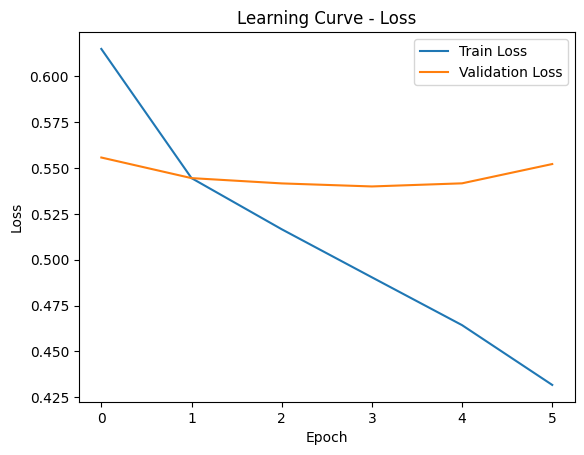

Training Loss per epoch:
[0.6150181293487549, 0.5445442795753479, 0.5166505575180054, 0.490436851978302, 0.4643397033214569, 0.43172794580459595]

Validation Loss per epoch:
[0.5557780265808105, 0.5445423722267151, 0.5416573286056519, 0.5399967432022095, 0.5416966676712036, 0.5522213578224182]

Training Accuracy per epoch:
[0.6554703116416931, 0.7226483225822449, 0.7438890933990479, 0.7624747157096863, 0.7816503643989563, 0.7997724413871765]

Validation Accuracy per epoch:
[0.7190542221069336, 0.7243646383285522, 0.7305601239204407, 0.7295486330986023, 0.7316980361938477, 0.7292957305908203]


In [ ]:
import matplotlib.pyplot as plt



# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.show()

# After model.fit()

print("Training Loss per epoch:")
print(history.history['loss'])

print("\nValidation Loss per epoch:")
print(history.history['val_loss'])

print("\nTraining Accuracy per epoch:")
print(history.history['accuracy'])

print("\nValidation Accuracy per epoch:")
print(history.history['val_accuracy'])



# 6. Add regularziation to adress overfitting

Epoch 1/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6008 - loss: 0.7562 - val_accuracy: 0.6971 - val_loss: 0.6384
Epoch 2/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7125 - loss: 0.6294 - val_accuracy: 0.7158 - val_loss: 0.6193
Epoch 3/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7212 - loss: 0.6174 - val_accuracy: 0.7208 - val_loss: 0.6122
Epoch 4/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7262 - loss: 0.6110 - val_accuracy: 0.7221 - val_loss: 0.6119
Epoch 5/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7261 - loss: 0.6066 - val_accuracy: 0.7271 - val_loss: 0.6083
Epoch 6/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7344 - loss: 0.5988 - val_accuracy: 0.7264 - val_loss: 0.6073
Epoch 7/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7389 - loss: 0.5963 - val_accuracy: 0.7279 - val_loss: 0.6062
Epoch 8/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7352 - loss: 0.5950 - val_accuracy: 0.

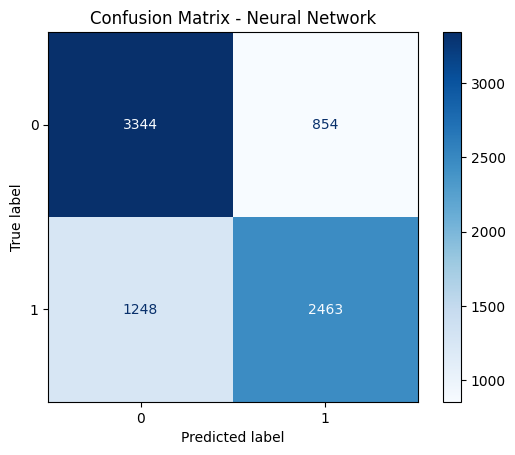

In [45]:
from tensorflow.keras.callbacks import EarlyStopping


import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2





# ---------- Load training data ----------
train_df = pd.read_csv("train_data.csv")
y_train = train_df["Is_Sarcastic"].values
text_train = train_df["comment/headline"]
numeric_train = train_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- Load validation data ----------
val_df = pd.read_csv("val_data.csv")
y_val = val_df["Is_Sarcastic"].values
text_val = val_df["comment/headline"]
numeric_val = val_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# ---------- TF-IDF vectorization ----------
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_text_train = tfidf.fit_transform(text_train)
X_text_val = tfidf.transform(text_val)

# ---------- Normalize numeric features ----------
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(numeric_train)
X_numeric_val = scaler.transform(numeric_val)

# ---------- Combine text and numeric features ----------
X_train = hstack([X_text_train, X_numeric_train]).toarray()
X_val = hstack([X_text_val, X_numeric_val]).toarray()

# ---------- Build basic neural network ----------
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


early_stop = EarlyStopping(
    monitor='val_loss',       # Watch validation loss
    patience=2,               # Stop if val_loss doesn't improve for 2 epochs
    restore_best_weights=True
)

# ---------- Compile the model ----------
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ---------- Train the model with EarlyStopping ----------
history = model.fit(
    X_train, y_train,
    epochs=10,                # Allow more epochs, EarlyStopping will cut it short
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],  # Add EarlyStopping callback here
    verbose=1
)

# ---------- Evaluate on validation set ----------
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")

# ---------- Generate classification report ----------
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues')
plt.title("Confusion Matrix - Neural Network")
plt.show()

In [17]:
# --- Load test data ---
test_df = pd.read_csv("test_data.csv")
text_test = test_df["comment/headline"]
numeric_test = test_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]]

# --- Transform test data ---
X_text_test = tfidf.transform(text_test)
X_numeric_test = scaler.transform(numeric_test)

# --- Combine features and convert to dense ---
X_test = hstack([X_text_test, X_numeric_test]).toarray()

# --- Predict with trained model ---
y_test_prob = model.predict(X_test)
y_test_pred = (y_test_prob > 0.5).astype(int).flatten()

# --- Evaluate if labels are available ---
if "Is_Sarcastic" in test_df.columns:
    y_test_true = test_df["Is_Sarcastic"].values
    print("\n--- Test Set Evaluation ---")
    print(classification_report(y_test_true, y_test_pred))
else:
    print("\n--- Predictions on Unlabeled Test Set ---")
    print(y_test_pred)

    # Optional: Save predictions to CSV
    pd.DataFrame({
        "comment/headline": test_df["comment/headline"],
        "Predicted_Is_Sarcastic": y_test_pred
    }).to_csv("test_predictions_nn.csv", index=False)


248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      4198
           1       0.70      0.69      0.69      3712

    accuracy                           0.71      7910
   macro avg       0.71      0.71      0.71      7910
weighted avg       0.71      0.71      0.71      7910



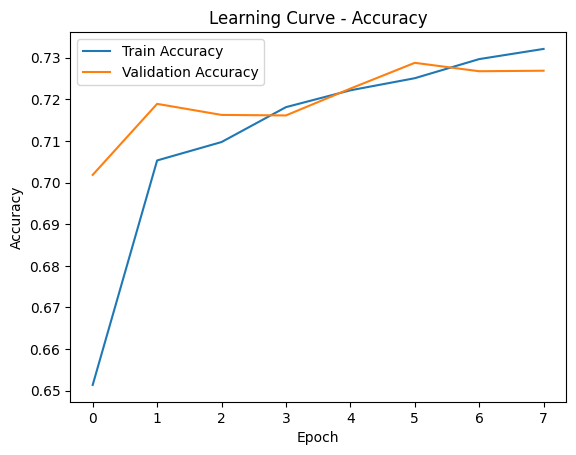

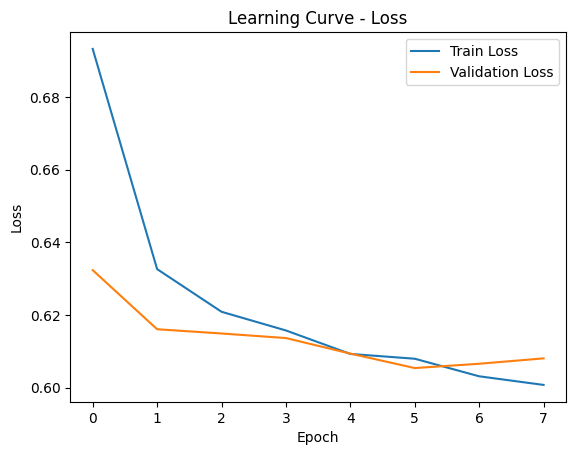

Training Loss per epoch:
[0.693232536315918, 0.6326366066932678, 0.6208964586257935, 0.6157494783401489, 0.6092908978462219, 0.6079736351966858, 0.6031383275985718, 0.6007654666900635]

Validation Loss per epoch:
[0.6323578953742981, 0.6160889863967896, 0.6149201989173889, 0.61366206407547, 0.609386146068573, 0.6054052114486694, 0.606591522693634, 0.6080726385116577]

Training Accuracy per epoch:
[0.651382327079773, 0.705327033996582, 0.7097522020339966, 0.7181389331817627, 0.7221847772598267, 0.7250927090644836, 0.729686439037323, 0.7321308255195618]

Validation Accuracy per epoch:
[0.701858639717102, 0.718927800655365, 0.7162725925445557, 0.7161461710929871, 0.7225944995880127, 0.7287899851799011, 0.7267670035362244, 0.726893424987793]


In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.show()

# After model.fit()

print("Training Loss per epoch:")
print(history.history['loss'])

print("\nValidation Loss per epoch:")
print(history.history['val_loss'])

print("\nTraining Accuracy per epoch:")
print(history.history['accuracy'])

print("\nValidation Accuracy per epoch:")
print(history.history['val_accuracy'])



# BONUS: TF-IDF has heavy limitations(Treats each word independently, ignoring context). We combine it with SBERT, built on transfomer architecture, which adds semantic context making the model more robust

Batches:   0%|          | 0/742 [00:00<?, ?it/s]

Batches:   0%|          | 0/248 [00:00<?, ?it/s]

Epoch 1/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.6513 - loss: 0.7488 - val_accuracy: 0.7381 - val_loss: 0.6066
Epoch 2/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7508 - loss: 0.5949 - val_accuracy: 0.7465 - val_loss: 0.5891
Epoch 3/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7660 - loss: 0.5746 - val_accuracy: 0.7579 - val_loss: 0.5778
Epoch 4/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7756 - loss: 0.5602 - val_accuracy: 0.7605 - val_loss: 0.5769
Epoch 5/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7765 - loss: 0.5604 - val_accuracy: 0.7594 - val_loss: 0.5840
Epoch 6/10
742/742 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7878 - loss: 0.5517 - val_accuracy: 0.7637 - val_loss: 0.5829
Validation Accuracy: 0.7605
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.76      0.80      0.78      4198
           1       0.76      0.71      0.74      371

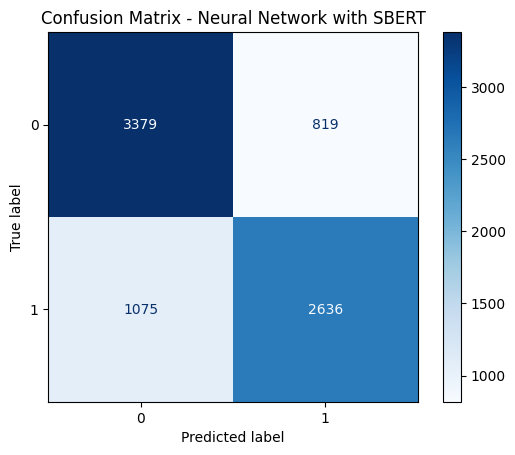

In [46]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

# Load data (your own paths)
train_df = pd.read_csv("train_data.csv")
val_df = pd.read_csv("val_data.csv")

y_train = train_df["Is_Sarcastic"].values
y_val = val_df["Is_Sarcastic"].values

text_train = train_df["comment/headline"].astype(str).tolist()
text_val = val_df["comment/headline"].astype(str).tolist()

numeric_train = train_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]].values
numeric_val = val_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]].values

# 1. TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_tfidf_train = tfidf.fit_transform(text_train)
X_tfidf_val = tfidf.transform(text_val)

# 2. SBERT embeddings
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
X_sbert_train = sbert_model.encode(text_train, batch_size=32, show_progress_bar=True)
X_sbert_val = sbert_model.encode(text_val, batch_size=32, show_progress_bar=True)

# 3. Numeric features normalization
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(numeric_train)
X_numeric_val = scaler.transform(numeric_val)

# 4. Combine features:
# Convert TF-IDF sparse matrix to dense arrays
X_tfidf_train_dense = X_tfidf_train.toarray()
X_tfidf_val_dense = X_tfidf_val.toarray()

# Horizontally stack TF-IDF, SBERT, and numeric features
X_train = np.hstack([X_tfidf_train_dense, X_sbert_train, X_numeric_train])
X_val = np.hstack([X_tfidf_val_dense, X_sbert_val, X_numeric_val])

# 5. Build NN model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Train
model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 7. Evaluate
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")

y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_val, y_pred))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred, cmap='Blues')
plt.title("Confusion Matrix - Neural Network with SBERT")
plt.show()


In [19]:
# --- Load test data ---
test_df = pd.read_csv("test_data.csv")
text_test = test_df["comment/headline"].astype(str).tolist()
numeric_test = test_df[["sentiment_score", "total_word_count", "exclamation_count", "question_count"]].values

# --- Transform test data using already fitted transformers/models ---
X_tfidf_test = tfidf.transform(text_test)
X_sbert_test = sbert_model.encode(text_test, batch_size=32, show_progress_bar=True)
X_numeric_test = scaler.transform(numeric_test)

# --- Combine all features ---
X_tfidf_test_dense = X_tfidf_test.toarray()
X_test = np.hstack([X_tfidf_test_dense, X_sbert_test, X_numeric_test])

# --- Predict ---
y_test_prob = model.predict(X_test)
y_test_pred = (y_test_prob > 0.5).astype(int).flatten()

# --- Evaluate if test labels are available ---
if "Is_Sarcastic" in test_df.columns:
    y_test_true = test_df["Is_Sarcastic"].values
    print("\n--- Test Set Evaluation ---")
    from sklearn.metrics import classification_report
    print(classification_report(y_test_true, y_test_pred))
else:
    print("\n--- Predictions on Unlabeled Test Set ---")
    print(y_test_pred)

    # Optionally save predictions
    pd.DataFrame({
        "comment/headline": test_df["comment/headline"],
        "Predicted_Is_Sarcastic": y_test_pred
    }).to_csv("test_predictions_sbert_nn.csv", index=False)


Batches:   0%|          | 0/248 [00:00<?, ?it/s]

248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Test Set Evaluation ---
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      4198
           1       0.75      0.73      0.74      3712

    accuracy                           0.76      7910
   macro avg       0.76      0.76      0.76      7910
weighted avg       0.76      0.76      0.76      7910



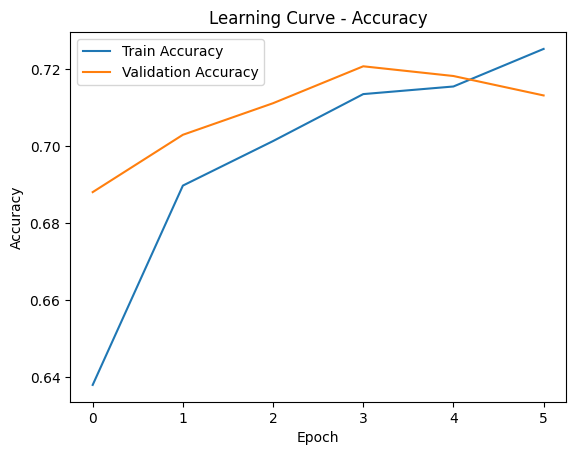

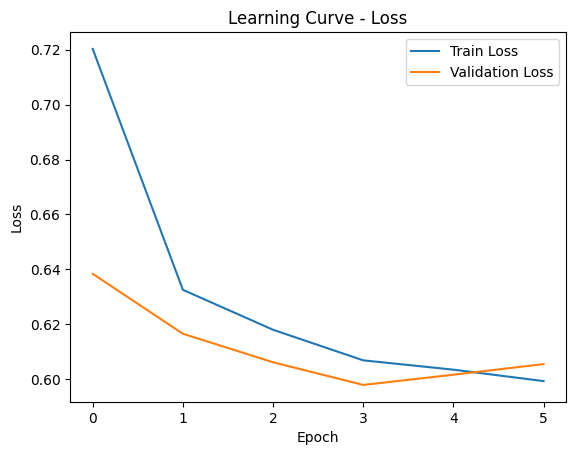

Training Loss per epoch:
[0.72024005651474, 0.6325848698616028, 0.6180534958839417, 0.6069255471229553, 0.603534460067749, 0.599372386932373]

Validation Loss per epoch:
[0.6384168267250061, 0.6166040897369385, 0.6062242984771729, 0.5979838371276855, 0.6016968488693237, 0.605570375919342]

Training Accuracy per epoch:
[0.6378961801528931, 0.6897757649421692, 0.7013654708862305, 0.7135873436927795, 0.7155681252479553, 0.7253456115722656]

Validation Accuracy per epoch:
[0.6880768537521362, 0.7029966115951538, 0.711215078830719, 0.7208243608474731, 0.7182956337928772, 0.7132380604743958]


In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Learning Curve - Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()
plt.show()

# After model.fit()

print("Training Loss per epoch:")
print(history.history['loss'])

print("\nValidation Loss per epoch:")
print(history.history['val_loss'])

print("\nTraining Accuracy per epoch:")
print(history.history['accuracy'])

print("\nValidation Accuracy per epoch:")
print(history.history['val_accuracy'])

